<a href="https://www.kaggle.com/code/lalit7881/bank-fraud-dataset?scriptVersionId=302118770" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thuandao/bank-transactions-dataset-for-fraud-detection/bank_transactions_data_2_augmented_clean_2.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/thuandao/bank-transactions-dataset-for-fraud-detection/bank_transactions_data_2_augmented_clean_2.csv")

In [3]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [4]:
df.tail()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
49995,TX049996,AC00314,69.23,1/28/2025,Debit,Las Vegas,D000546,44.67.137.125,M097,Online,69,Doctor,69,1,6020.29
49996,TX049997,AC00370,514.53,1/23/2022,Debit,Houston,D000589,140.212.253.222,M061,ATM,46,Engineer,143,1,6371.51
49997,TX049998,AC00277,118.39,11/8/2022,Debit,Omaha,D000217,152.140.239.181,M029,Online,33,Doctor,296,1,749.34
49998,TX049999,AC00007,446.99,4/20/2025,Debit,Las Vegas,D000327,131.41.45.13,M082,ATM,58,Doctor,11,1,10915.11
49999,TX050000,AC00427,84.82,11/19/2020,Debit,Dallas,D000355,192.163.114.167,M078,Branch,31,Doctor,23,1,842.56


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [6]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [7]:
df.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

TransactionID           object
AccountID               object
TransactionAmount      float64
TransactionDate         object
TransactionType         object
Location                object
DeviceID                object
IP Address              object
MerchantID              object
Channel                 object
CustomerAge              int64
CustomerOccupation      object
TransactionDuration      int64
LoginAttempts            int64
AccountBalance         float64
dtype: object

In [10]:
df.shape

(50000, 15)

In [11]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')

In [12]:
df.nunique()

TransactionID          50000
AccountID                495
TransactionAmount      34837
TransactionDate         6373
TransactionType            2
Location                  43
DeviceID                 681
IP Address               592
MerchantID               100
Channel                    3
CustomerAge               63
CustomerOccupation         4
TransactionDuration      288
LoginAttempts              5
AccountBalance          2510
dtype: int64

In [13]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    format='mixed',
    errors='coerce'
)

# extract features
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['Day'] = df['TransactionDate'].dt.day

print(df[['TransactionDate','Year','Month','Day']].head())

      TransactionDate  Year  Month  Day
0 2023-04-11 16:29:00  2023      4   11
1 2023-06-27 16:44:00  2023      6   27
2 2023-07-10 18:16:00  2023      7   10
3 2023-05-05 16:32:00  2023      5    5
4 2023-10-16 17:51:00  2023     10   16


## Data visualizations

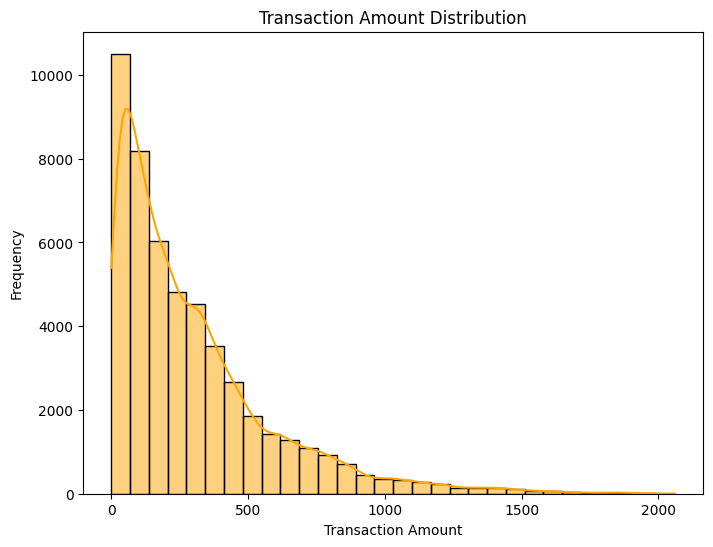

In [14]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['TransactionAmount'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

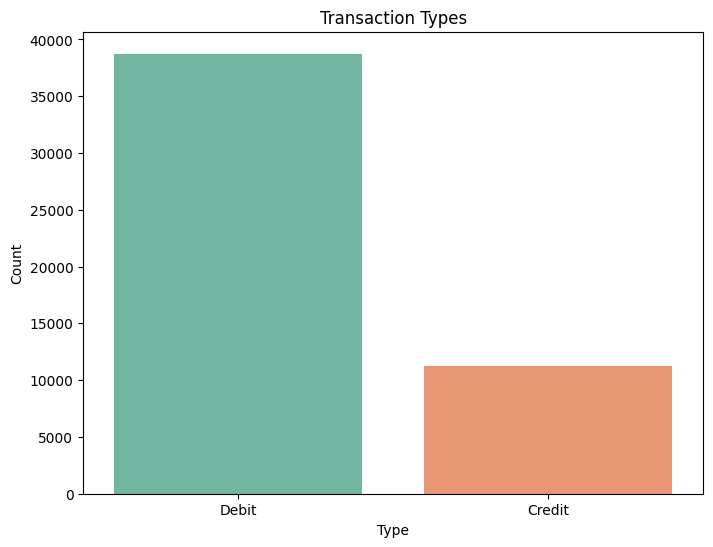

In [15]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='TransactionType',
    data=df,
    palette='Set2'
)

plt.title("Transaction Types")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

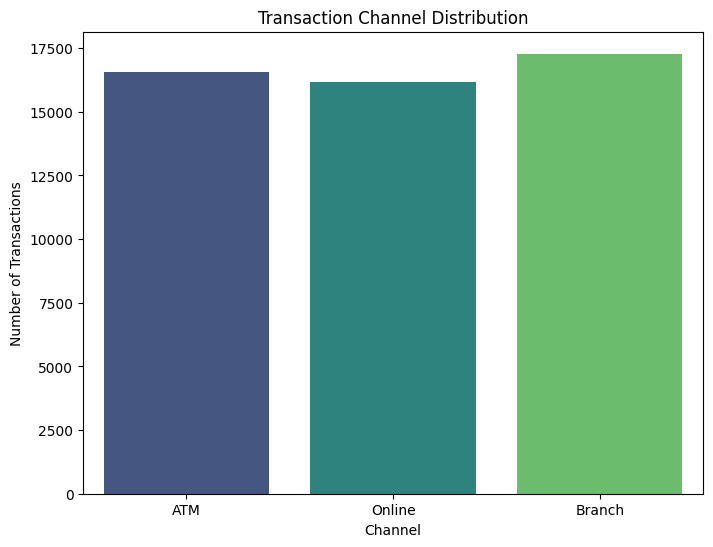

In [16]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='Channel',
    data=df,
    palette='viridis'
)

plt.title("Transaction Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")

plt.show()

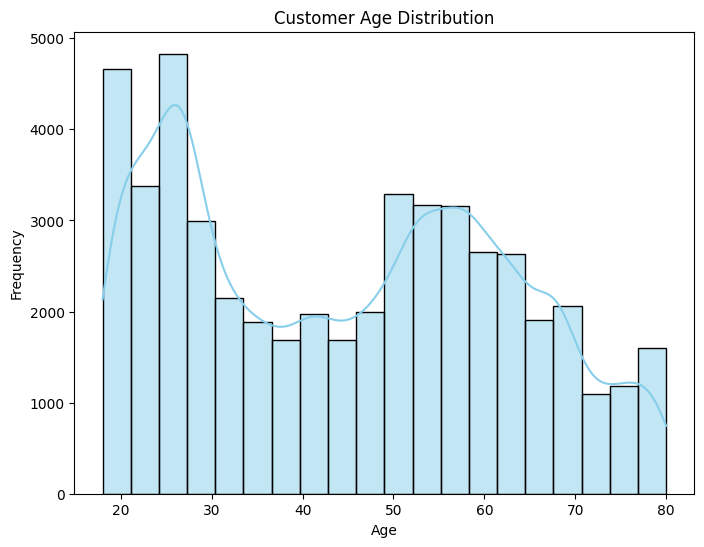

In [17]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['CustomerAge'],
    bins=20,
    color='skyblue',
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

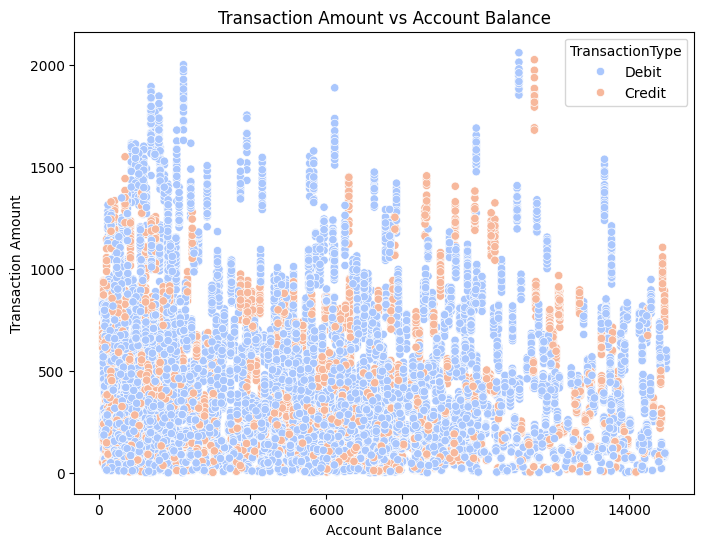

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='AccountBalance',
    y='TransactionAmount',
    hue='TransactionType',
    palette='coolwarm',
    data=df
)

plt.title("Transaction Amount vs Account Balance")
plt.xlabel("Account Balance")
plt.ylabel("Transaction Amount")

plt.show()

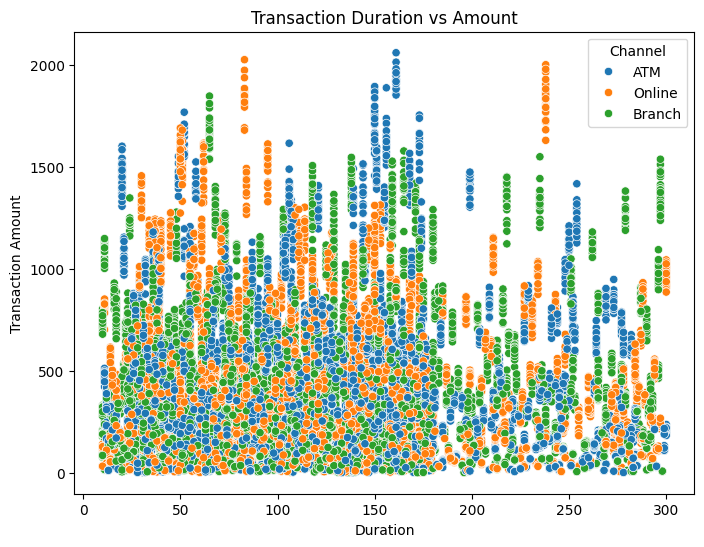

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='TransactionDuration',
    y='TransactionAmount',
    hue='Channel',
    palette='tab10',
    data=df
)

plt.title("Transaction Duration vs Amount")
plt.xlabel("Duration")
plt.ylabel("Transaction Amount")

plt.show()

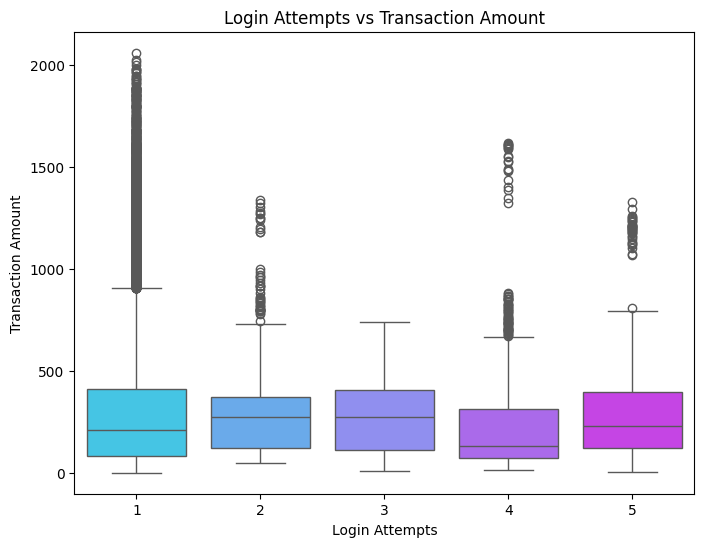

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='LoginAttempts',
    y='TransactionAmount',
    palette='cool',
    data=df
)

plt.title("Login Attempts vs Transaction Amount")
plt.xlabel("Login Attempts")
plt.ylabel("Transaction Amount")

plt.show()

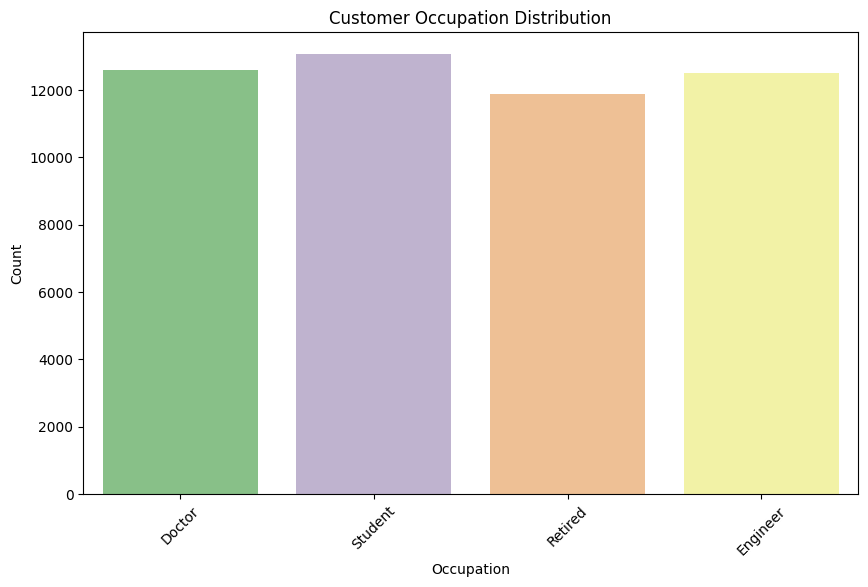

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='CustomerOccupation',
    palette='Accent',
    data=df
)

plt.title("Customer Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

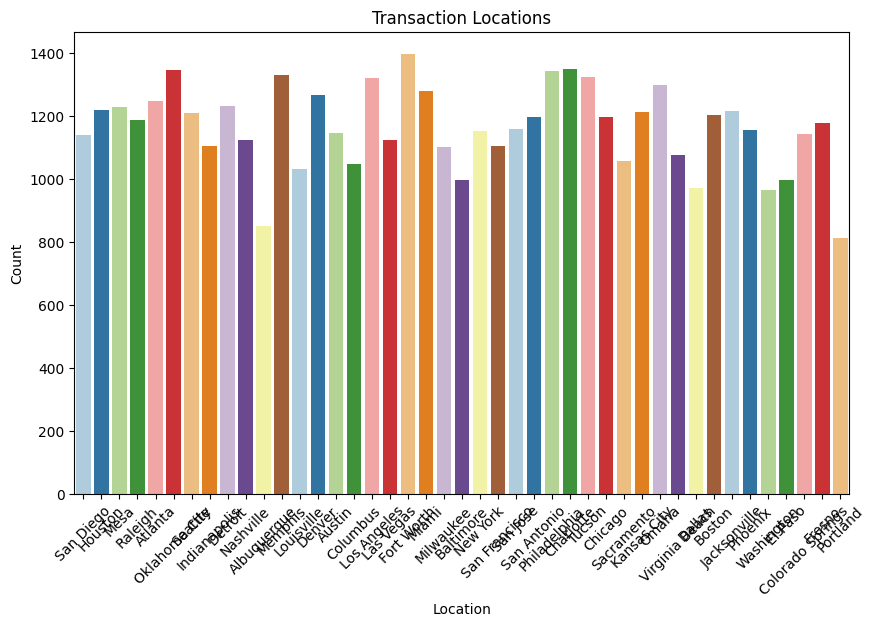

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Location',
    palette='Paired',
    data=df
)

plt.title("Transaction Locations")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

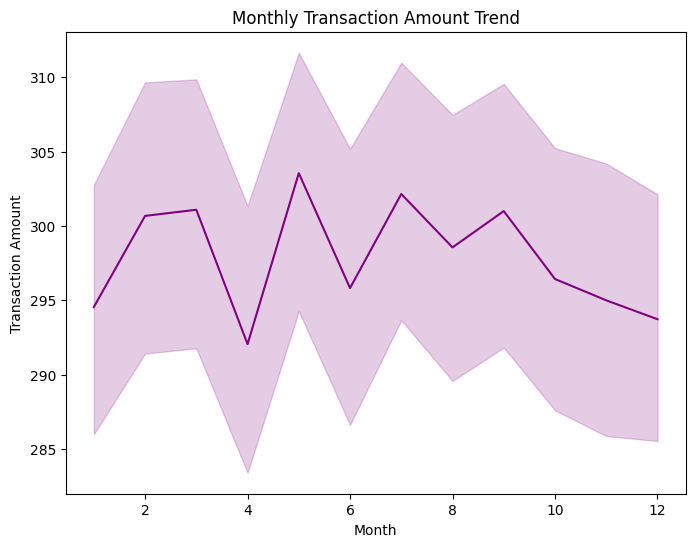

In [23]:
plt.figure(figsize=(8,6))

sns.lineplot(
    x='Month',
    y='TransactionAmount',
    data=df,
    color='purple'
)

plt.title("Monthly Transaction Amount Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")

plt.show()

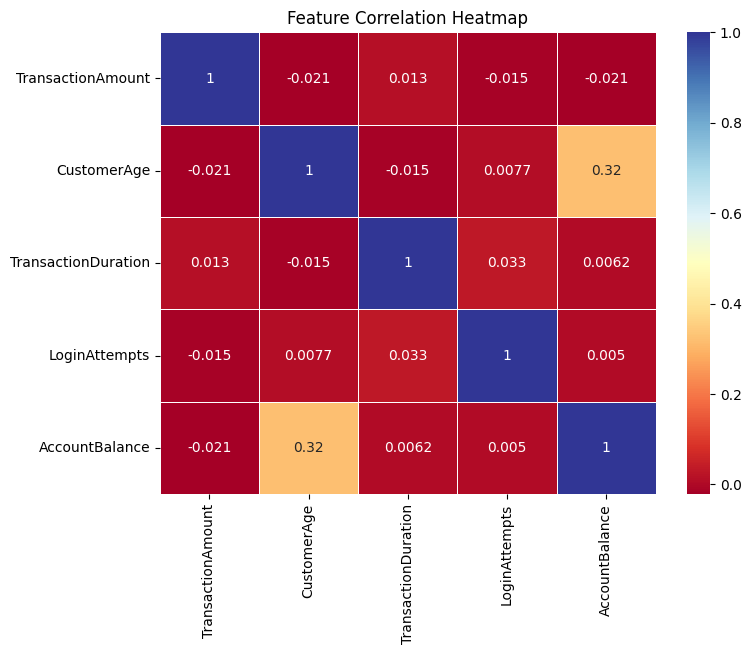

In [24]:
numeric_cols = [
'TransactionAmount',
'CustomerAge',
'TransactionDuration',
'LoginAttempts',
'AccountBalance'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='RdYlBu',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

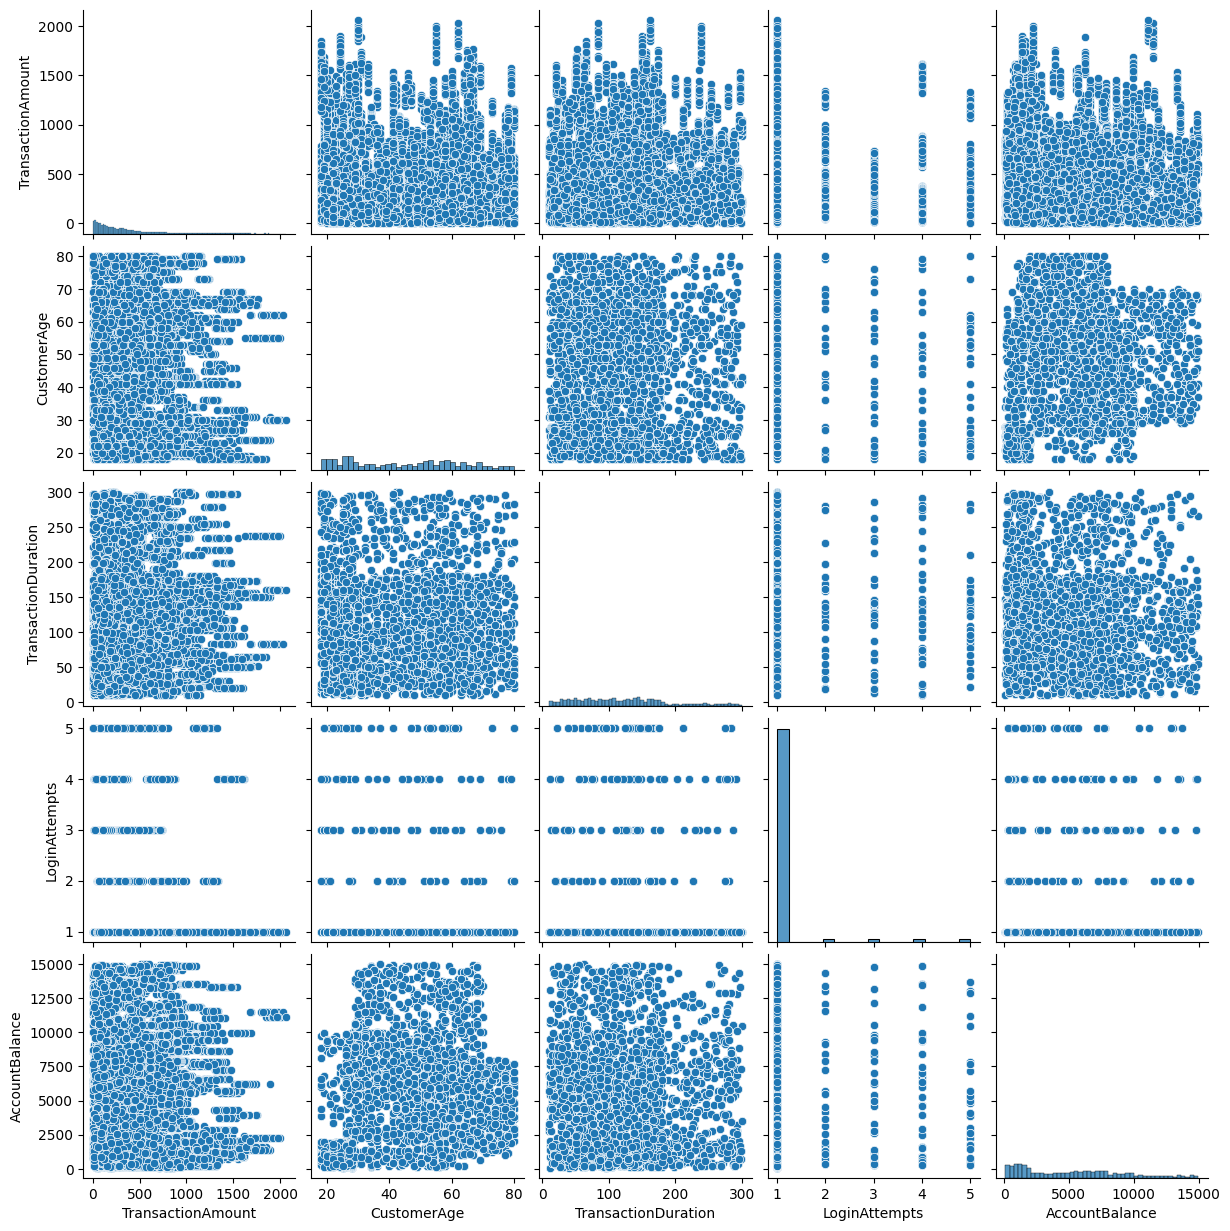

In [25]:
sns.pairplot(
    df[numeric_cols],
    palette='husl'
)

plt.show()

## Feature engineering

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [27]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed', errors='coerce')

df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['Day'] = df['TransactionDate'].dt.day

df.drop('TransactionDate', axis=1, inplace=True)

In [28]:
df = df.drop([
'TransactionID',
'AccountID',
'DeviceID',
'IP Address',
'MerchantID'
], axis=1)

In [29]:
le = LabelEncoder()

categorical_cols = [
'TransactionType',
'Location',
'Channel',
'CustomerOccupation'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [30]:
X = df.drop('TransactionType', axis=1)

y = df['TransactionType']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [32]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}


MODEL : Logistic Regression
Accuracy : 77.58 %


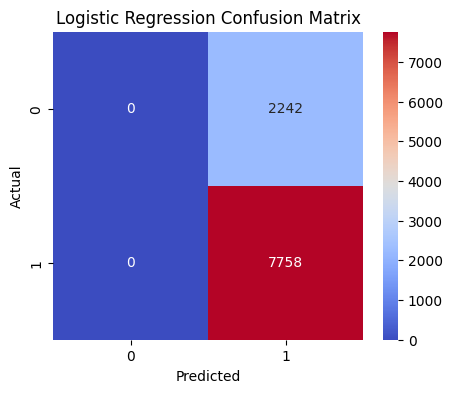

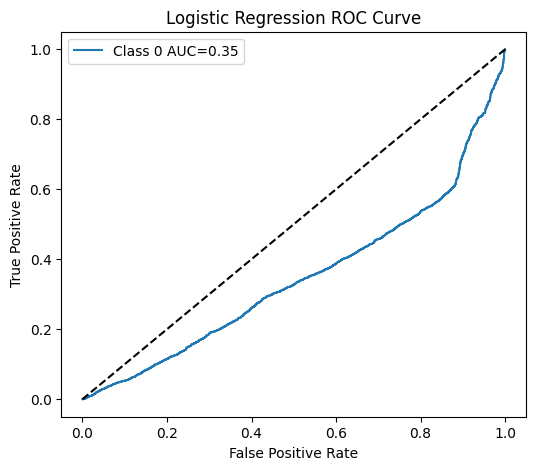


MODEL : Decision Tree
Accuracy : 99.79 %


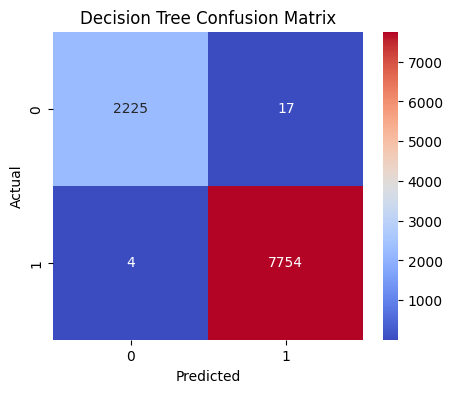

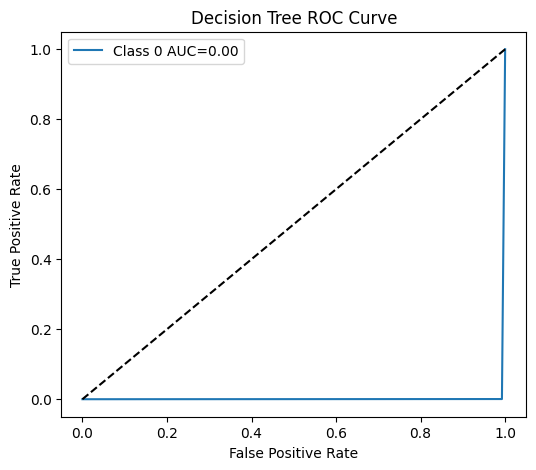


MODEL : Random Forest
Accuracy : 100.0 %


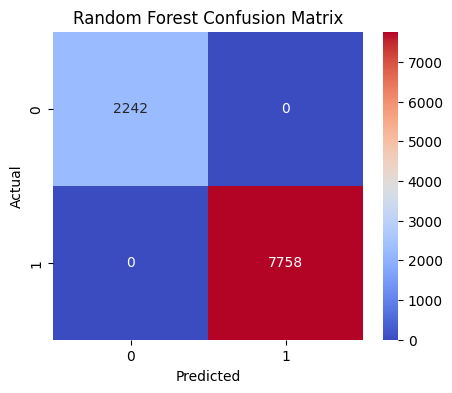

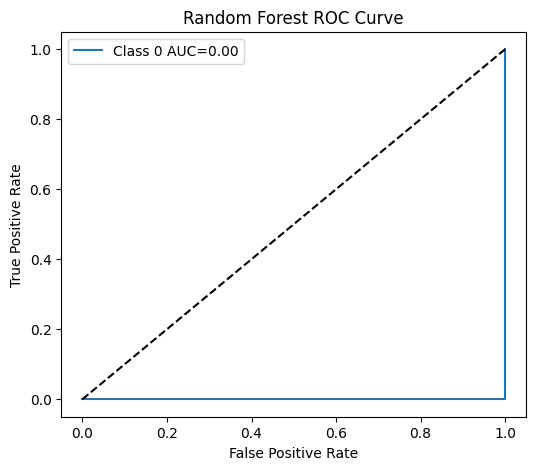


MODEL : KNN
Accuracy : 99.81 %


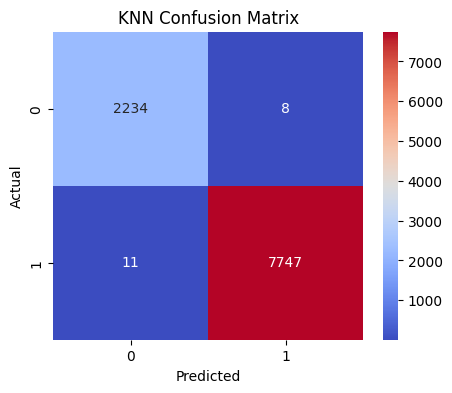

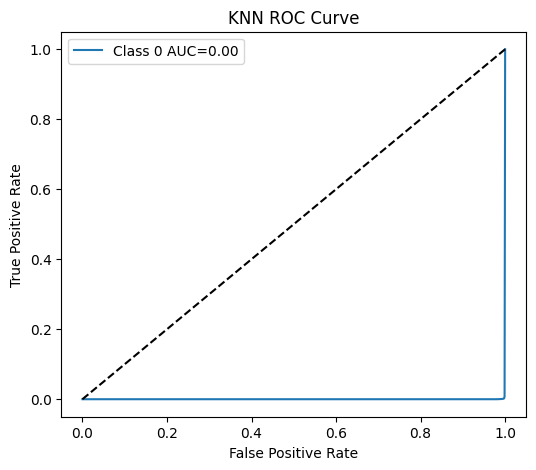


MODEL : Naive Bayes
Accuracy : 76.96 %


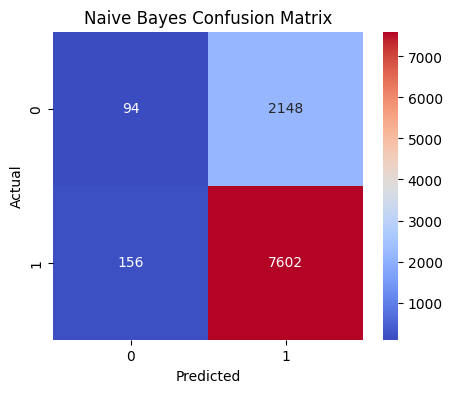

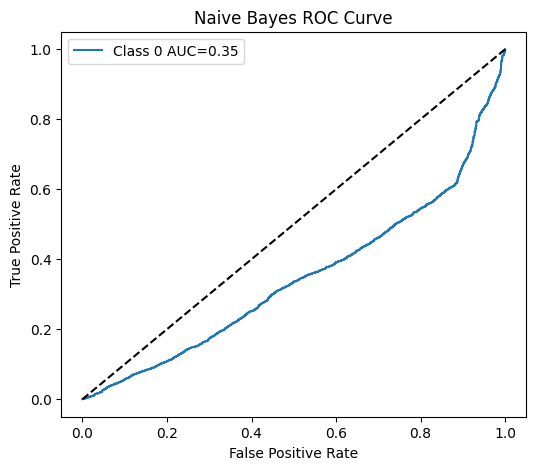

In [33]:
for name, model in models.items():

    print("\n"+"="*60)
    print("MODEL :", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)*100

    print("Accuracy :", round(accuracy,2), "%")


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm'
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


    # ROC Curve
    y_prob = model.predict_proba(X_test)

    y_test_bin = label_binarize(y_test, classes=np.unique(y))

    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(6,5))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"Class {i} AUC={roc_auc:.2f}"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.title(name + " ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

## Thank you..pls upvote!!!!!!!!